# Practice Lab Neural Network 1
## Neural Network Implementation from Scratch

**Institute:** MIT Academy of Engineering, Alandi, Pune  
**Class:** T.Y. B.Tech  
**Course:** Generative AI Lab  
**Department:** CSE AIML  

### Student Information
- **Name:** Snehal Pagare
- **PRN Number:** 202502110003
- **Batch:** A3
- **Date of Submission:** 19-08-2026



## Part A — Objective

The objective is to implement a simple feedforward neural network from scratch in Python without TensorFlow, Keras, PyTorch, or other built-in deep-learning frameworks.

The implementation covers:
- Dataset loading and preprocessing
- Network architecture
- Weight and bias initialization
- ReLU activation
- Softmax activation
- Forward propagation
- Categorical cross-entropy loss
- Backpropagation
- Gradient descent
- Training
- Prediction and accuracy evaluation
- Visualization of training loss and predictions


## Part B — Problem Definition

### Dataset
The **Iris dataset** contains 150 flower samples belonging to three species:
1. Iris-setosa
2. Iris-versicolor
3. Iris-virginica

Each sample has four numerical features:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

### Task
This is a **multiclass classification** problem. The neural network receives four measurements and predicts one of the three Iris species.


## Part C — Import Libraries

Only basic Python scientific-computing libraries are used. The neural-network mathematics is implemented manually using NumPy.


In [21]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)

print("Libraries imported successfully.")

Libraries imported successfully.


## Part D — Load and Inspect Dataset

In [22]:

data = pd.read_csv("iris.csv")

print("Dataset shape:", data.shape)

print("\nColumns:")
print(list(data.columns))

print("\nFirst five rows:")
display(data.head())

print("\nClass distribution:")
print(data["Species"].value_counts())

Dataset shape: (150, 5)

Columns:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

First five rows:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Class distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## Part E — Data Preprocessing

Steps:
1. Separate features and target.
2. Convert class names into integer labels.
3. One-hot encode the target.
4. Shuffle and split the data into 80% training and 20% testing.
5. Standardize using **training-set statistics only**.

Using training statistics avoids data leakage from the test set.


In [23]:

# Separate features and target
X_all = data[
    ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
].to_numpy(dtype=float)

species = data["Species"].to_numpy()

# Label encoding
label_map = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
}

y_all = np.array([label_map[name] for name in species])

# One-hot encoding
num_classes = 3

Y_all = np.zeros((len(y_all), num_classes))
Y_all[np.arange(len(y_all)), y_all] = 1.0

# Shuffle and split
rng = np.random.default_rng(7)

indices = rng.permutation(len(X_all))

split = int(0.80 * len(X_all))

train_idx = indices[:split]
test_idx = indices[split:]

X_train_raw = X_all[train_idx]
X_test_raw = X_all[test_idx]

Y_train = Y_all[train_idx]
Y_test = Y_all[test_idx]

y_train = y_all[train_idx]
y_test = y_all[test_idx]

# Standardization using training data only
mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)

sigma[sigma == 0] = 1.0

X_train = (X_train_raw - mu) / sigma
X_test = (X_test_raw - mu) / sigma

print("Training shape:", X_train.shape, Y_train.shape)
print("Testing shape :", X_test.shape, Y_test.shape)

Training shape: (120, 4) (120, 3)
Testing shape : (30, 4) (30, 3)


## Part F — Neural Network Architecture

The network has the following structure:

**4 → 8 → 3**

- Input layer: 4 neurons
- Hidden layer: 8 neurons with ReLU
- Output layer: 3 neurons with Softmax

The output represents probabilities for the three Iris classes.


## Part G — Initialize Parameters

Weights are initialized with small random values and biases with zeros.

- W1: 4 × 8
- b1: 1 × 8
- W2: 8 × 3
- b2: 1 × 3


In [24]:
def initialize_parameters(n_input=4, n_hidden=8, n_output=3):
    rng = np.random.default_rng(7)

    W1 = rng.normal(0, np.sqrt(2 / n_input), size=(n_input, n_hidden))
    b1 = np.zeros((1, n_hidden))

    W2 = rng.normal(0, np.sqrt(2 / n_hidden), size=(n_hidden, n_output))
    b2 = np.zeros((1, n_output))

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

params = initialize_parameters()

for name, value in params.items():
    print(name, value.shape)


W1 (4, 8)
b1 (1, 8)
W2 (8, 3)
b2 (1, 3)


## Part H — Activation Functions

### ReLU
ReLU is used in the hidden layer:

**ReLU(x) = max(0, x)**

Its derivative is 1 for positive values and 0 otherwise.

### Softmax
Softmax converts the output scores into probabilities whose sum is 1.


In [25]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    # Numerical-stability adjustment
    shifted = x - np.max(x, axis=1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values, axis=1, keepdims=True)

test = np.array([[-2.0, 0.0, 3.0]])
print("ReLU:", relu(test))
print("ReLU derivative:", relu_derivative(test))
print("Softmax:", softmax(test))


ReLU: [[0. 0. 3.]]
ReLU derivative: [[0. 0. 1.]]
Softmax: [[0.00637746 0.04712342 0.94649912]]


## Part I — Forward Propagation

During the forward pass:

1. Z1 = XW1 + b1
2. A1 = ReLU(Z1)
3. Z2 = A1W2 + b2
4. A2 = Softmax(Z2)

A2 contains the predicted class probabilities.


In [26]:
def forward_pass(X, p):
    Z1 = X @ p["W1"] + p["b1"]
    A1 = relu(Z1)

    Z2 = A1 @ p["W2"] + p["b2"]
    A2 = softmax(Z2)

    cache = {"Z1": Z1, "A1": A1, "A2": A2}
    return A2, cache

sample_probs, cache = forward_pass(X_train[:5], params)
print("Output probabilities for first 5 samples:")
print(sample_probs)


Output probabilities for first 5 samples:
[[2.23764389e-01 7.72640144e-04 7.75462971e-01]
 [3.42310181e-01 3.10754723e-01 3.46935096e-01]
 [4.00287839e-01 1.33573710e-01 4.66138452e-01]
 [3.60416097e-01 2.12315840e-01 4.27268063e-01]
 [3.51163062e-01 2.87851338e-01 3.60985600e-01]]


## Part J — Categorical Cross-Entropy Loss

For multiclass classification:

**Loss = -(1/m) Σ y log(ŷ)**

A small epsilon is used to avoid log(0).


In [27]:
def cross_entropy(Y_true, Y_pred):
    eps = 1e-12
    clipped = np.clip(Y_pred, eps, 1.0 - eps)
    return -np.mean(np.sum(Y_true * np.log(clipped), axis=1))

print("Example loss:", cross_entropy(
    np.array([[1, 0, 0]]),
    np.array([[0.90, 0.05, 0.05]])
))


Example loss: 0.10536051565782628


## Part K — Backpropagation

Backpropagation calculates how much each parameter contributed to the loss.

For Softmax + Cross-Entropy:

**dZ2 = A2 - Y**

Then the gradients are propagated to the hidden layer using the chain rule.


In [28]:
def backward_pass(X, Y, cache, p):
    m = X.shape[0]

    Z1 = cache["Z1"]
    A1 = cache["A1"]
    A2 = cache["A2"]

    # Output layer
    dZ2 = A2 - Y
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Hidden layer
    dA1 = dZ2 @ p["W2"].T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

grads = backward_pass(X_train[:5], Y_train[:5], cache, params)

for name, value in grads.items():
    print(name, value.shape)


dW1 (4, 8)
db1 (1, 8)
dW2 (8, 3)
db2 (1, 3)


## Part L — Gradient Descent

The parameters are updated using:

**parameter = parameter − learning_rate × gradient**

This moves the network parameters in the direction that reduces the loss.


In [29]:
def update_parameters(p, g, learning_rate):
    p["W1"] -= learning_rate * g["dW1"]
    p["b1"] -= learning_rate * g["db1"]
    p["W2"] -= learning_rate * g["dW2"]
    p["b2"] -= learning_rate * g["db2"]

epochs = 1000
learning_rate = 0.08
loss_history = []

params = initialize_parameters()

for epoch in range(1, epochs + 1):
    # Forward pass
    probabilities, cache = forward_pass(X_train, params)

    # Loss
    loss = cross_entropy(Y_train, probabilities)
    loss_history.append(loss)

    # Backpropagation
    gradients = backward_pass(X_train, Y_train, cache, params)

    # Gradient descent
    update_parameters(params, gradients, learning_rate)

    if epoch == 1 or epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss:.6f}")

print("Training completed.")


Epoch    1 | Loss: 1.476831
Epoch  100 | Loss: 0.379189
Epoch  200 | Loss: 0.245399
Epoch  300 | Loss: 0.167765
Epoch  400 | Loss: 0.123219
Epoch  500 | Loss: 0.097694
Epoch  600 | Loss: 0.082055
Epoch  700 | Loss: 0.071805
Epoch  800 | Loss: 0.064775
Epoch  900 | Loss: 0.059624
Epoch 1000 | Loss: 0.055678
Training completed.


## Part M — Loss Visualization

A decreasing loss indicates that the neural network is learning from the training data.


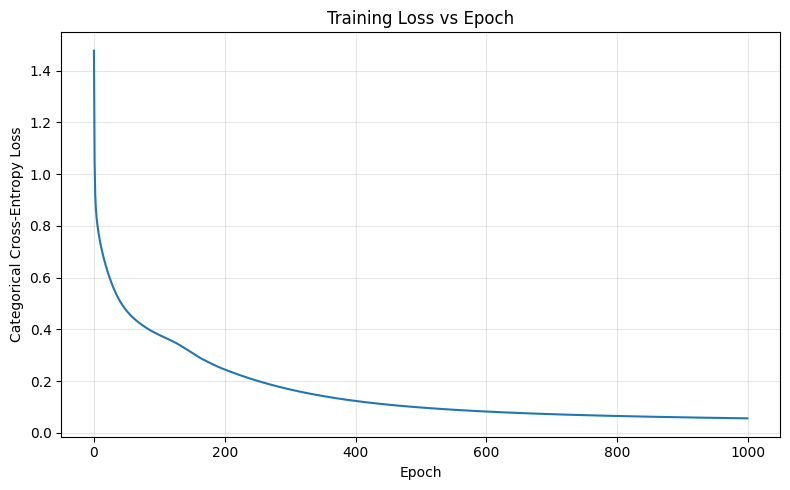

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Categorical Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()


## Part N — Prediction and Accuracy

In [31]:
def predict(X, p):
    probabilities, _ = forward_pass(X, p)
    return np.argmax(probabilities, axis=1)

test_pred = predict(X_test, params)
accuracy = np.mean(test_pred == y_test)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Correct predictions: {np.sum(test_pred == y_test)} / {len(y_test)}")
print(f"Incorrect predictions: {np.sum(test_pred != y_test)} / {len(y_test)}")


Test Accuracy: 96.67%
Correct predictions: 29 / 30
Incorrect predictions: 1 / 30


## Part O — Sample Prediction Results

In [32]:
reverse_map = {v: k for k, v in label_map.items()}

prediction_table = pd.DataFrame({
    "Actual": [reverse_map[i] for i in y_test],
    "Predicted": [reverse_map[i] for i in test_pred],
})

prediction_table["Correct"] = prediction_table["Actual"] == prediction_table["Predicted"]
display(prediction_table.head(15))


,Actual,Predicted,Correct
0,Iris-versicolor,Iris-versicolor,True
1,Iris-virginica,Iris-virginica,True
2,Iris-virginica,Iris-virginica,True
3,Iris-virginica,Iris-virginica,True
4,Iris-setosa,Iris-setosa,True
5,Iris-virginica,Iris-virginica,True
6,Iris-setosa,Iris-setosa,True
7,Iris-virginica,Iris-virginica,True
8,Iris-versicolor,Iris-versicolor,True
9,Iris-versicolor,Iris-versicolor,True


## Part P — Performance Visualization

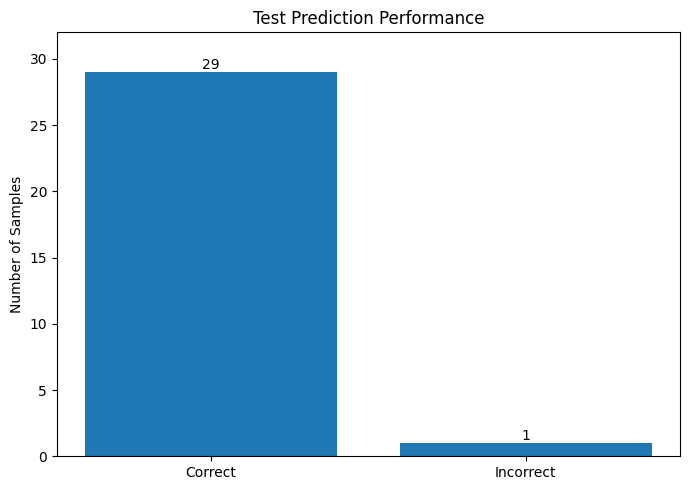

In [33]:
correct = int(np.sum(test_pred == y_test))
incorrect = int(np.sum(test_pred != y_test))

plt.figure(figsize=(7, 5))
bars = plt.bar(["Correct", "Incorrect"], [correct, incorrect])
plt.title("Test Prediction Performance")
plt.ylabel("Number of Samples")
plt.ylim(0, len(y_test) + 2)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        str(int(bar.get_height())),
        ha="center"
    )

plt.tight_layout()
plt.savefig("prediction_performance.png", dpi=150)
plt.show()


## Part Q — Results and Discussion

The model's final performance is printed by the previous cell, so the reported accuracy should be copied from the actual execution result rather than manually assumed.

### Discussion
- Training loss should decrease as epochs increase.
- The model learns the relationship between flower measurements and species.
- Standardization makes gradient descent more stable.
- The test accuracy indicates how well the trained network generalizes to unseen samples.
- Any incorrect predictions can occur because some Iris classes have overlapping feature measurements.


## Part R — Conclusion

A feedforward neural network was implemented from scratch using Python and NumPy.

The assignment demonstrated:
- Data preprocessing
- One-hot encoding
- Parameter initialization
- ReLU and Softmax
- Forward propagation
- Cross-entropy loss
- Backpropagation
- Gradient descent
- Training
- Prediction
- Accuracy evaluation
- Visualization

This implementation provides a clear understanding of the mathematical operations performed internally by neural-network frameworks.


## Declaration

I, **Snehal Pagare**, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines.

**GitHub Repository Link:** https://github.com/snehalpagare272005-jpg/

**Signature:** Snehal Pagare

